# EDA 2 (Interim) - RECH6: Antropometría y Anemia (Estructura Temática)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
import pandas as pd
from mnp.config import INTERIM_DATA_DIR

DATA_PATH = INTERIM_DATA_DIR / "rech6_cleaned.parquet"

print(f"Cargando datos desde: {DATA_PATH}")
df_rech6 = pd.read_parquet(DATA_PATH)

print(f"Filas: {len(df_rech6):,}")
print(f"Columnas: {len(df_rech6.columns)}")
df_rech6.head()


2026-06-15 09:30:40.486 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


Cargando datos desde: /Users/abelguevarah/Desktop/invs/malnutrition-research/data/interim/rech6_cleaned.parquet
Filas: 294,109
Columnas: 38


,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,...,HC60,HC61,HC62,HC63,HC64,HC70,HC71,HC72,HC73,year
0,1 10,3,20.0,9.6,76.6,177.0,-2.10,9201.0,830.0,-1.38,...,2,3.0,3.0,NaN,1.0,-2.14,-0.92,0.18,0.57,2007
1,1 22,5,28.0,13.7,83.2,468.0,-1.68,9355.0,6255.0,0.32,...,2,1.0,5.0,101.0,3.0,-2.21,0.48,2.32,2.68,2007
2,1 34,3,40.0,12.8,92.0,956.0,-1.31,9481.0,948.0,-1.31,...,2,3.0,2.0,NaN,1.0,-1.53,-1.08,-0.30,-0.15,2007
3,26 3,4,52.0,17.6,109.0,8757.0,1.15,10461.0,6560.0,0.40,...,3,1.0,3.0,80.0,3.0,0.83,0.29,-0.37,-0.31,2007
4,26 3,5,34.0,13.2,83.4,37.0,-2.68,8935.0,2494.0,-0.68,...,3,1.0,3.0,18.0,4.0,-3.12,-0.48,1.85,2.35,2007


## 1. Sesgo Operativo y Demográfico (Calidad del Muestreo del INEI)\nEsta sección evalúa si la recolección de datos del INEI sufrió sesgos en los 18 años.

### 1.0 Tamaño de Muestra Anual (Volumen de Datos)

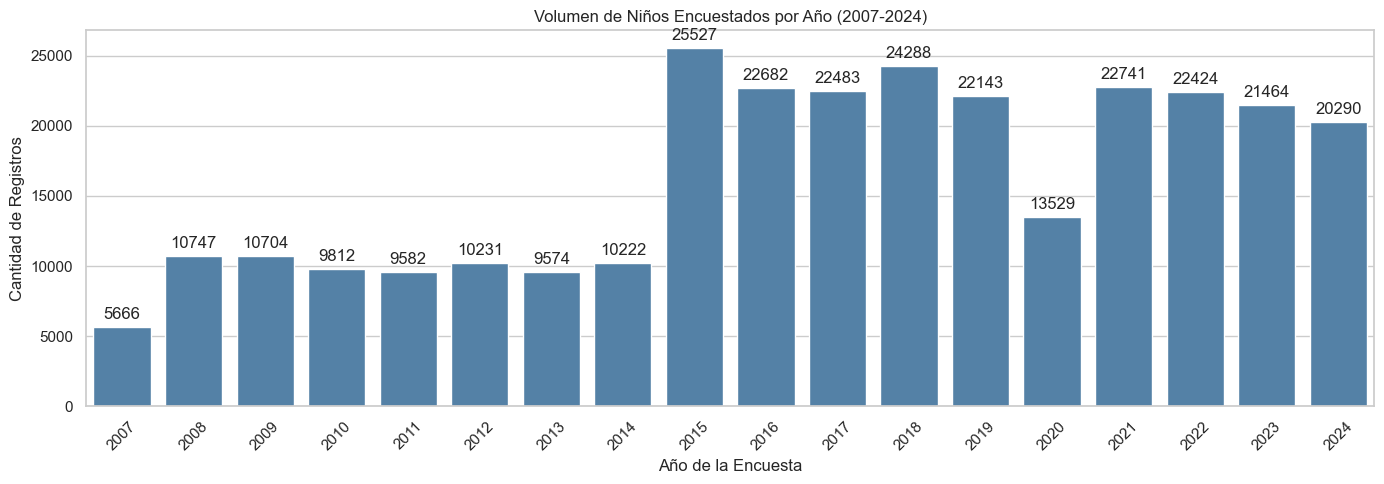

In [3]:
# Evolución del tamaño del dataset por año
plt.figure(figsize=(14, 5))
ax = sns.countplot(data=df_rech6, x='year', color='steelblue')
plt.title('Volumen de Niños Encuestados por Año (2007-2024)')
plt.ylabel('Cantidad de Registros')
plt.xlabel('Año de la Encuesta')
plt.xticks(rotation=45)

# Añadir etiquetas de texto encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

> **Conclusión y Acción (Tamaño de Muestra Histórico)**
> * **Observación:** El volumen de encuestas muestra un **salto estructural masivo** a partir de 2015. En la primera mitad histórica (2007-2014), el INEI levantaba muestras relativamente moderadas (alrededor de 10,000 niños anuales). Sin embargo, a partir de 2015 la capacidad operativa **se duplicó radicalmente**, saltando a más de 22,000-25,000 registros por año. Se nota también el colapso predecible del año 2020 (cayendo a 13,529) debido a las cuarentenas estrictas por la pandemia de COVID-19.
> * **Acción a Tomar:** **Estrategia de Modelado Temporal.** Esta distribución asimétrica en realidad **nos favorece**, ya que los años más recientes (y más representativos de la realidad actual) contienen el doble de datos que los años antiguos. Aún así, para evitar que un modelo asigne demasiada importancia a los años con sobredensidad poblacional, debemos entrenar incorporando el año como variable y realizar una validación cruzada temporal (*Time-Series Split*). Probaremos la eficacia del modelo aislando exclusivamente los últimos años (ej. 2022-2024) como set de validación intocable.

### 1.1 Distribución de Edades Encuestadas (Sesgo Temporal)

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_44379/1959183149.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_edad, x='year', y='HC1', palette='viridis', fliersize=1)


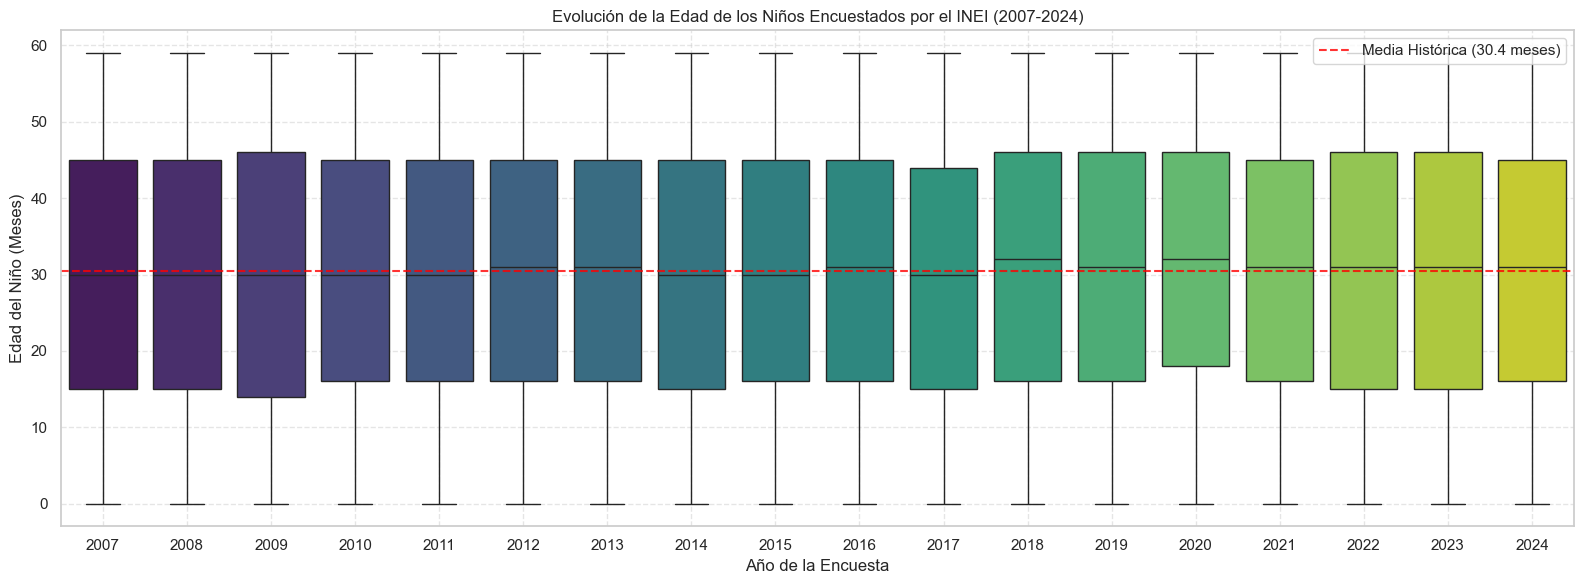

In [4]:
# Verificamos si el INEI cambió su enfoque de edades (0 a 59 meses) a lo largo del tiempo
df_edad = df_rech6.dropna(subset=['HC1'])

plt.figure(figsize=(16, 6))
sns.boxplot(data=df_edad, x='year', y='HC1', palette='viridis', fliersize=1)

media_historica = df_edad['HC1'].mean()
plt.axhline(media_historica, color='red', linestyle='--', alpha=0.8, label=f'Media Histórica ({media_historica:.1f} meses)')

plt.title('Evolución de la Edad de los Niños Encuestados por el INEI (2007-2024)')
plt.ylabel('Edad del Niño (Meses)')
plt.xlabel('Año de la Encuesta')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> **Conclusión y Acción (Distribución de Edades)**
> * **Observación:** La mediana de edad de los niños encuestados se ha mantenido estadísticamente congelada en **30.4 meses** durante los 18 años del estudio. El bloque intercuartílico (cajas) es prácticamente idéntico año tras año.
> * **Acción a Tomar:** **Validación Aprobada.** No existe sesgo demográfico temporal por edad (*Age Drift*). Podemos cruzar y comparar los índices de desnutrición del 2007 contra los del 2024 directamente, sin necesidad de aplicar técnicas estadísticas de re-ponderación (re-weighting). Esto garantiza que cualquier caída en la desnutrición crónica será una mejora de salud real y no un espejismo estadístico causado por encuestar a niños de edades distintas.

### 1.2 Verificación de Sesgo de Género (HC27)

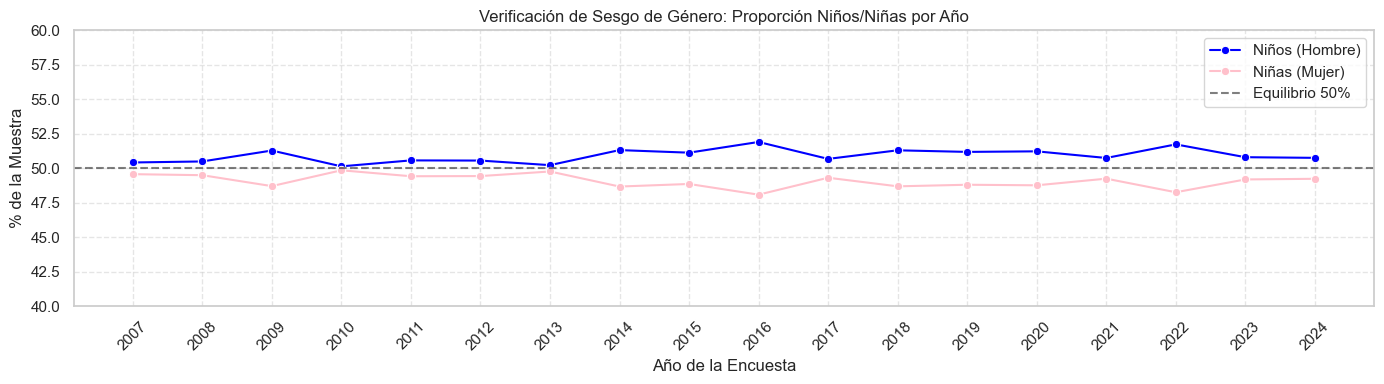

In [5]:
# Evolución del Sexo del Niño (Verificación de Sesgo de Género)
if 'HC27' in df_rech6.columns:
    df_sexo = df_rech6.dropna(subset=['HC27'])
    sex_year = pd.crosstab(df_sexo['year'], df_sexo['HC27'], normalize='index') * 100
    
    plt.figure(figsize=(14, 4))
    cols = sex_year.columns.tolist()
    if len(cols) >= 2:
        sns.lineplot(x=sex_year.index, y=sex_year[cols[0]], marker='o', label=f'Niños ({cols[0]})', color='blue')
        sns.lineplot(x=sex_year.index, y=sex_year[cols[1]], marker='o', label=f'Niñas ({cols[1]})', color='pink')
        
    plt.axhline(50, color='black', linestyle='--', alpha=0.5, label='Equilibrio 50%')
    
    plt.title('Verificación de Sesgo de Género: Proporción Niños/Niñas por Año')
    plt.ylabel('% de la Muestra')
    plt.xlabel('Año de la Encuesta')
    plt.xticks(ticks=sex_year.index, labels=[str(int(y)) for y in sex_year.index], rotation=45)
    plt.ylim(40, 60) # Enfocamos para ver pequeñas variaciones
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

> **Conclusión y Acción (Sesgo de Género)**
> * **Observación:** La proporción de la muestra ha permanecido casi estática a través de los 18 años, orbitando de manera constante el equilibrio natural de **~51% Niños y ~49% Niñas**. Las líneas de tendencia son planas, paralelas al eje de equilibrio del 50%, y carecen de fluctuaciones anómalas en ningún sexenio.
> * **Acción a Tomar:** **Validación Aprobada.** Queda descartado cualquier sesgo demográfico de género en la selección de los infantes medidos por el INEI. Al ser una base de datos estructuralmente paritaria, no se requiere aplicar técnicas de re-balanceo de clases (*upsampling/downsampling*) por género, ni estratificar obligatoriamente los futuros modelos de Machine Learning para compensar problemas de muestreo.

## 2. Auditoría de Valores Nulos (Missing Data en HC70)

### 2.1 Evolución Histórica de los Nulos en HC70

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_44379/3413560032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos_por_ano.index, y=nulos_por_ano.values, palette="viridis")


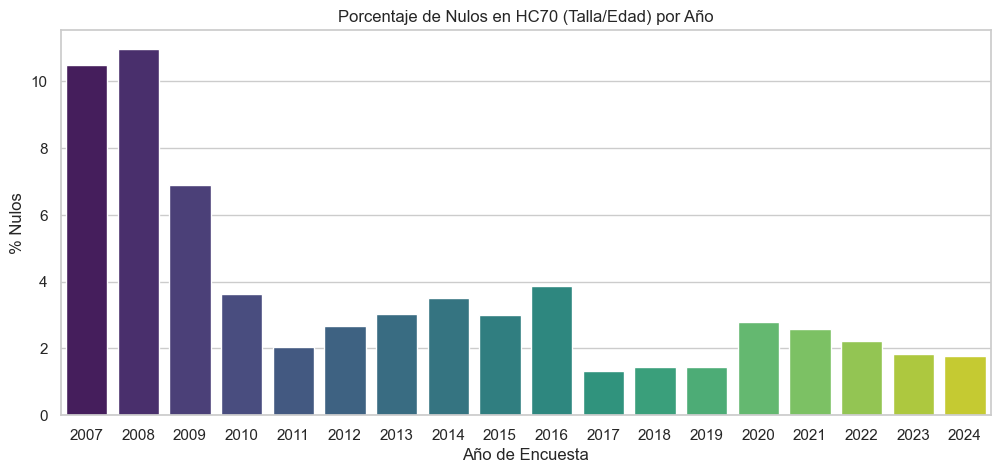

In [6]:
nulos_por_ano = df_rech6.groupby('year')['HC70'].apply(lambda x: x.isna().mean() * 100)

plt.figure(figsize=(12, 5))
sns.barplot(x=nulos_por_ano.index, y=nulos_por_ano.values, palette="viridis")
plt.title("Porcentaje de Nulos en HC70 (Talla/Edad) por Año")
plt.ylabel("% Nulos")
plt.xlabel("Año de Encuesta")
plt.show()

> **Conclusión y Acción (Evolución Histórica de Nulos)**
> * **Observación:** Existe una mejora dramática en la calidad operativa del INEI con el paso del tiempo. Los años **2007 y 2008** muestran una tasa crítica de datos faltantes (más del 10% de los niños encuestados no fueron tallados). Sin embargo, a partir de la década de 2010, la tasa de error se desploma y estabiliza en un nivel excelente (menos del 4%), notándose apenas un ligero bache en 2020 explicable por las restricciones físicas de la pandemia de COVID-19.
> * **Acción a Tomar:** **Depuración Segura (Drop NA).** Dado que la variable `HC70` es nuestro *Target* (Lo que vamos a predecir), no podemos inventar ni imputar estos datos. Como el porcentaje de pérdida en los años recientes es absolutamente marginal (menos del 2%), procederemos a eliminar las filas sin `HC70` de la base de datos de Machine Learning. El siguiente gráfico validará la excusa exacta de por qué no se les midió en 2007-2008.

### 2.2 Sesgo de Nulos (MNAR) - Razón de No Medición (HC13)

Razones por las que el niño NO fue medido (cuando HC70 es nulo):
HC13
Rechazó                3560
No presente            2867
Otro                   1432
Medido                  876
Parcialmente medido      80
NaN                      10
Name: count, dtype: int64


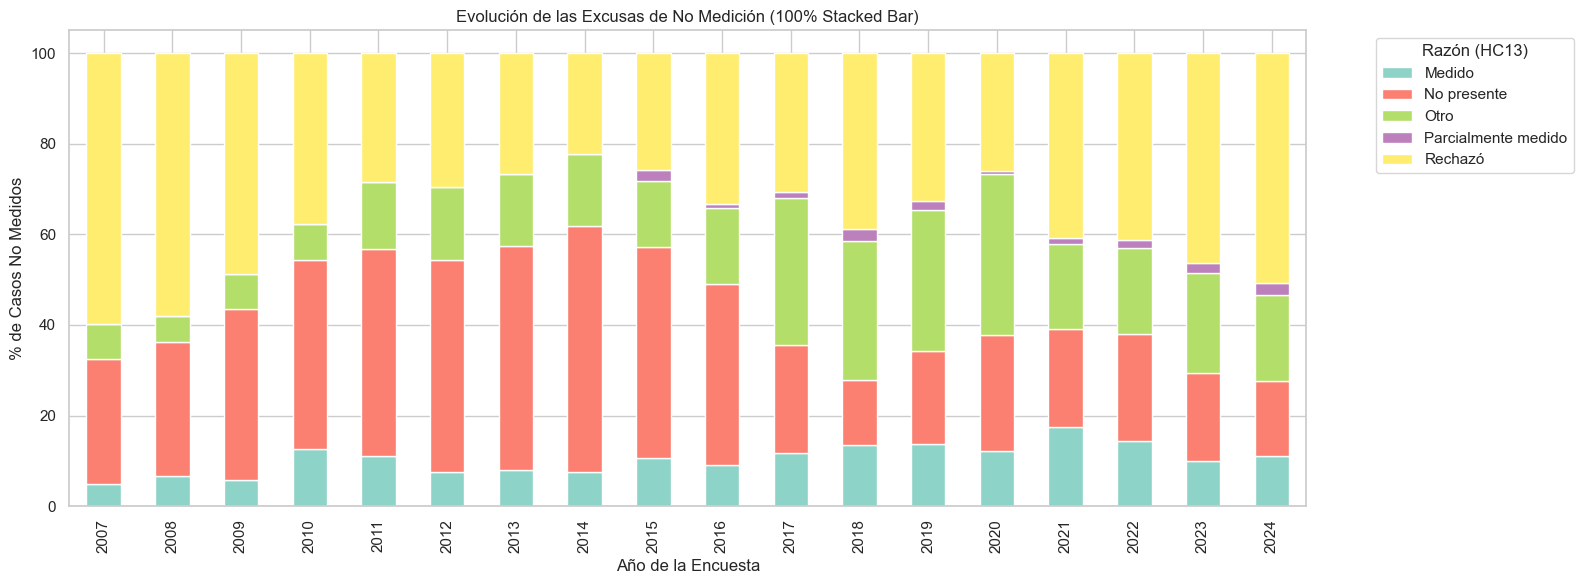

In [7]:
# Filtrar solo a los niños que NO tienen HC70 y ver su razón en HC13
nulos_hc70 = df_rech6[df_rech6['HC70'].isna()]
razon_nulos = nulos_hc70['HC13'].value_counts(dropna=False)
print("Razones por las que el niño NO fue medido (cuando HC70 es nulo):")
print(razon_nulos)

# Evolución de la Razón de No Medición (Sesgo Operativo)
if 'HC13' in df_rech6.columns:
    df_no_medidos = df_rech6[df_rech6['HC70'].isna()].copy()
    df_no_medidos = df_no_medidos.dropna(subset=['HC13'])
    
    if not df_no_medidos.empty:
        motivos_ano = pd.crosstab(df_no_medidos['year'], df_no_medidos['HC13'], normalize='index') * 100
        motivos_ano.plot(kind='bar', stacked=True, figsize=(16, 6), colormap='Set3')
        plt.title('Evolución de las Excusas de No Medición (100% Stacked Bar)')
        plt.ylabel('% de Casos No Medidos')
        plt.xlabel('Año de la Encuesta')
        plt.legend(title='Razón (HC13)', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

> **Conclusión y Acción (Sesgo de No Medición - MNAR)**
> * **Observación:** Los datos faltantes de Talla/Edad **no son aleatorios (MNAR)**, están fuertemente ligados al comportamiento humano. En 2007-2009, la pérdida masiva de datos (vista en el gráfico anterior) fue impulsada abrumadoramente por la categoría **"Rechazó"** (barra amarilla), indicando resistencia o desconfianza de las madres a la medición física en los primeros años del estudio. En la década de 2010, el motivo principal cambió a **"No presente"** (barra roja). Es alarmante notar una persistente barra celeste ("Medido"): un error operativo crónico donde el encuestador marcó al niño como medido en la hoja de control, pero dejó la casilla del resultado biométrico en blanco.
> * **Acción a Tomar:** **Confirmación de Drop NA.** Al estar frente a datos faltantes sistemáticos (MNAR) impulsados por rechazo o ausencia, usar algoritmos de imputación matemática (como rellenar con la media o KNN) es estadísticamente inválido y alteraría la realidad médica. Reafirmamos la decisión técnica de eliminar definitivamente del dataset las filas que no contengan la medición física, garantizando que el modelo se entrene 100% con evidencia empírica real.

## 3. Análisis del Target (Desnutrición Crónica - HC70)

### 3.1 Auditoría de Variables Clínicas Clave Z-Scores

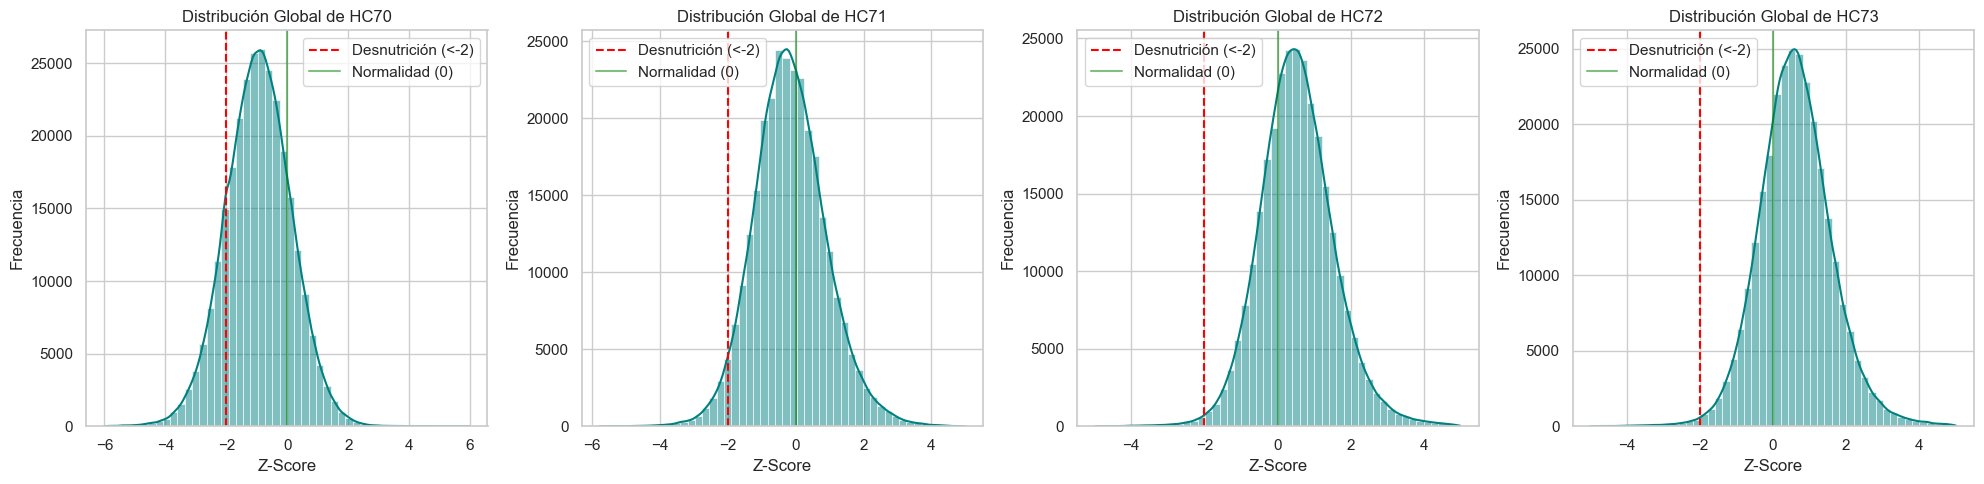

In [8]:
# 1. Distribución Global (Agregada de los 18 años) de las Variables Clínicas
cols_clinicas = ['HC70', 'HC71', 'HC72', 'HC73']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(cols_clinicas):
    sns.histplot(df_rech6[col].dropna(), bins=50, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución Global de {col}')
    axes[i].set_xlabel('Z-Score')
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(-2.0, color='red', linestyle='--', label='Desnutrición (<-2)')
    axes[i].axvline(0.0, color='green', linestyle='-', alpha=0.5, label='Normalidad (0)')
    axes[i].legend()

plt.tight_layout()
plt.show()

> **Conclusión y Acción (Distribución Global)**
> * **Observación:** Al observar las campanas de Gauss agregando todos los años, se confirma visualmente el problema estructural desde una perspectiva panorámica. La campana de `HC70` (Talla/Edad) es la única que está visiblemente desplazada hacia la izquierda (valores negativos), con una gruesa porción de su "cola" cayendo directamente en la zona roja de desnutrición (<-2.0). En contraste, las campanas de `HC71` (Peso/Talla) y `HC73` (IMC) están perfectamente centradas en el 0 verde de la OMS, o incluso levemente desplazadas hacia la derecha (sobrepeso).
> * **Acción a Tomar:** **Confirmación Cruzada.** La fotografía global ratifica matemáticamente lo hallado en el análisis año por año. Perú tiene un déficit crónico de crecimiento longitudinal en su población infantil, pero no tiene problemas de inanición o bajo peso severo. Esto cimenta la decisión de que todos los esfuerzos analíticos y predictivos deben volcarse en `HC70`.

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_44379/3213757444.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid, x='year', y=col, palette='viridis', fliersize=1)


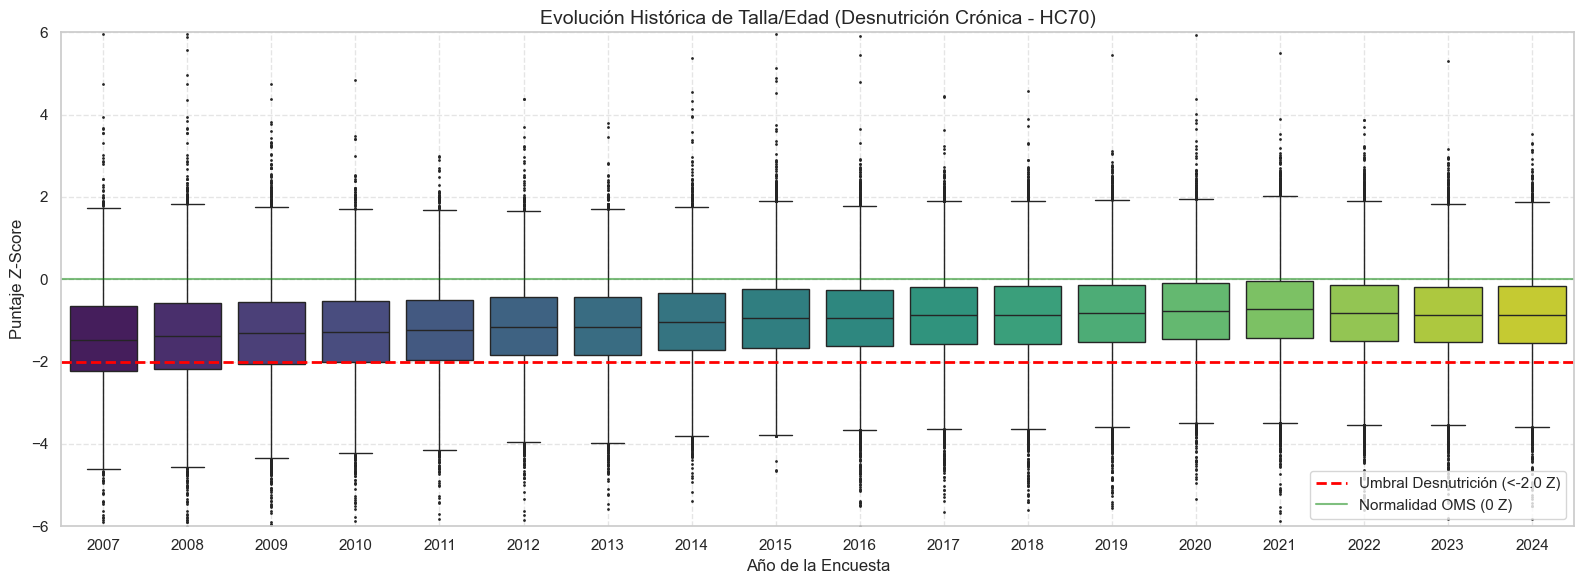

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_44379/3213757444.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid, x='year', y=col, palette='viridis', fliersize=1)


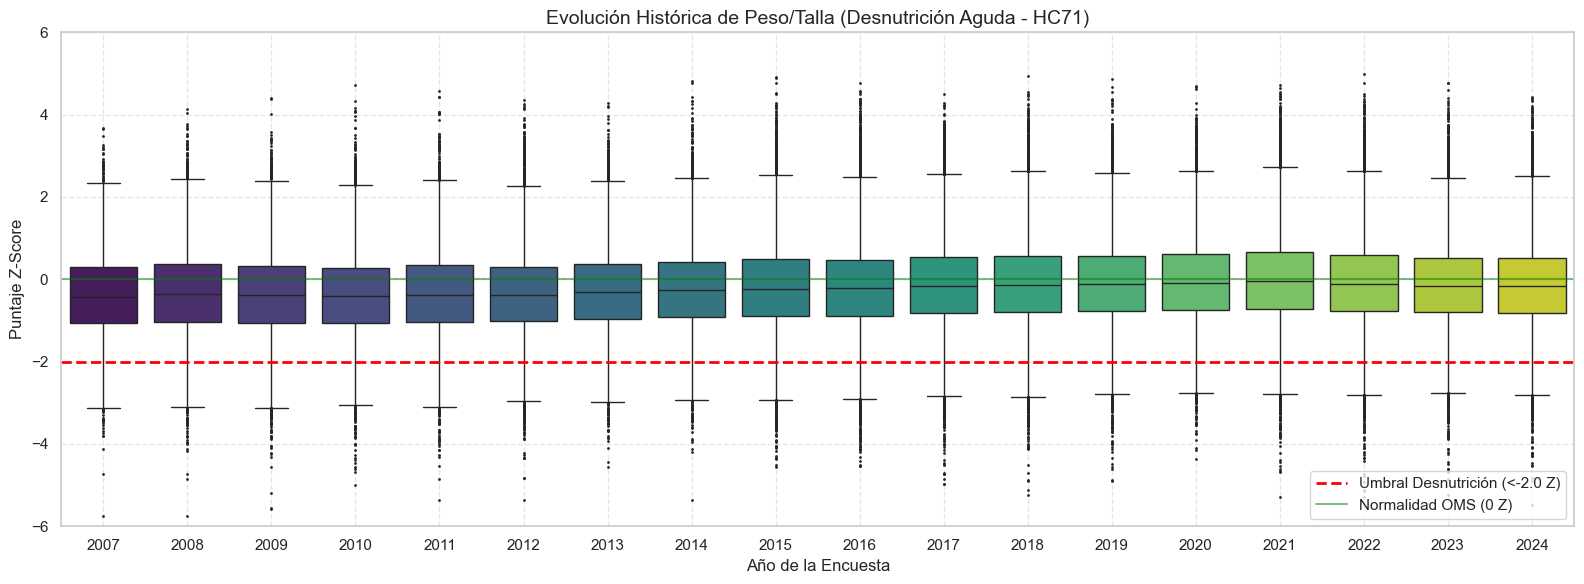

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_44379/3213757444.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid, x='year', y=col, palette='viridis', fliersize=1)


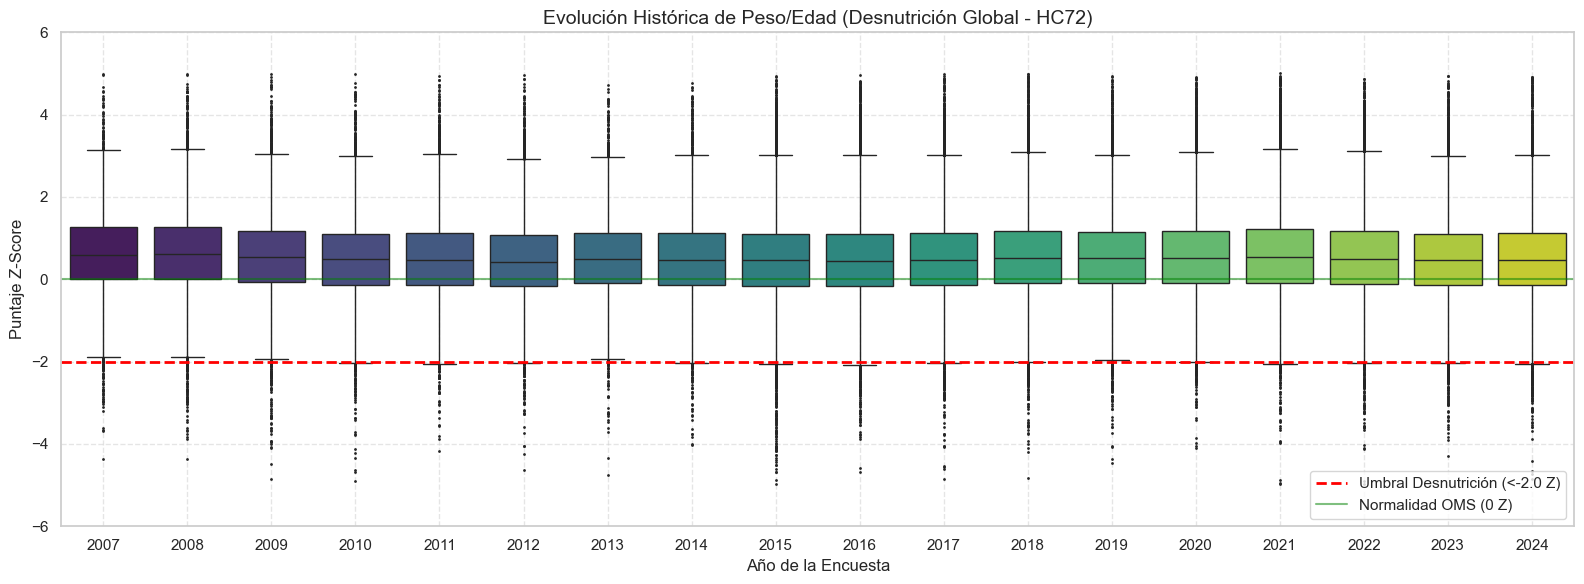

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_44379/3213757444.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid, x='year', y=col, palette='viridis', fliersize=1)


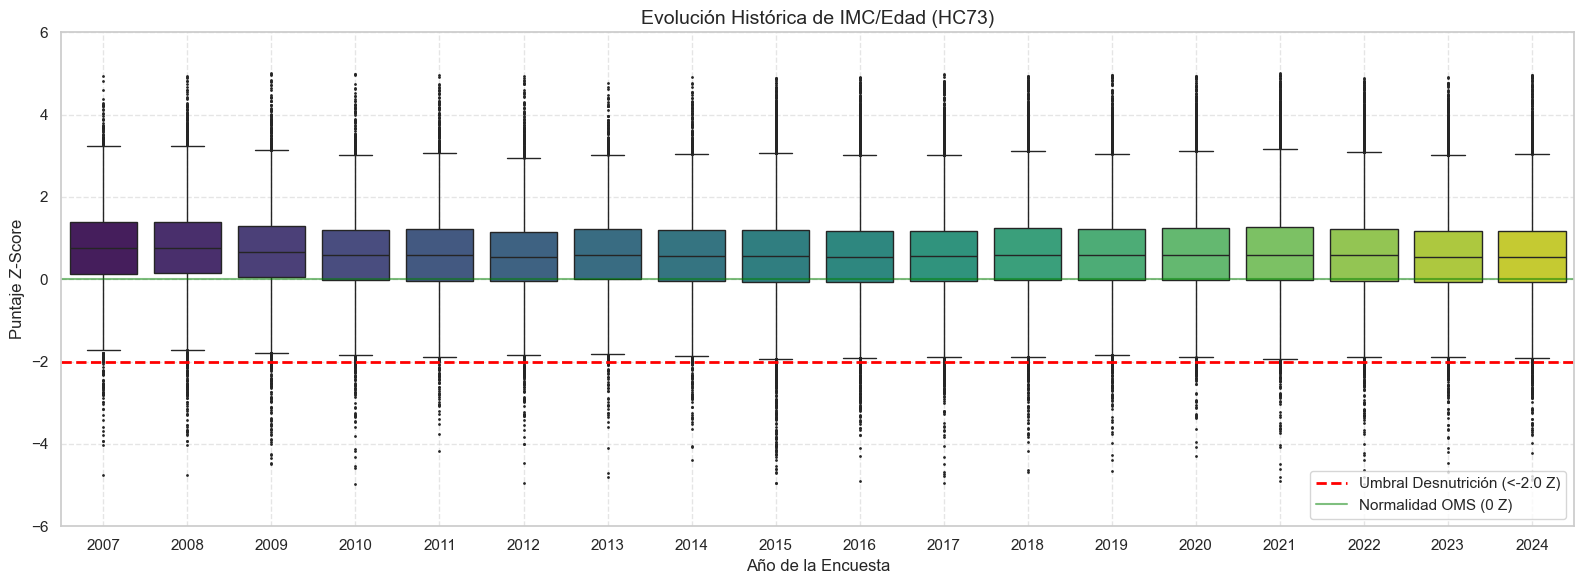

In [9]:
# Evolución Histórica de Variables Clínicas Clave (Target Drift)
# Analizamos cada métrica clínica por separado a través de los años
cols_clinicas = ['HC70', 'HC71', 'HC72', 'HC73']
nombres = ['Talla/Edad (Desnutrición Crónica - HC70)', 
           'Peso/Talla (Desnutrición Aguda - HC71)', 
           'Peso/Edad (Desnutrición Global - HC72)', 
           'IMC/Edad (HC73)']

for i, col in enumerate(cols_clinicas):
    df_valid = df_rech6.dropna(subset=[col])
    
    plt.figure(figsize=(16, 6))
    sns.boxplot(data=df_valid, x='year', y=col, palette='viridis', fliersize=1)
    
    # Umbral clínico de desnutrición
    plt.axhline(-2.0, color='red', linestyle='--', linewidth=2, label='Umbral Desnutrición (<-2.0 Z)')
    
    # Línea de normalidad absoluta de la OMS (Z = 0)
    plt.axhline(0.0, color='green', linestyle='-', alpha=0.5, label='Normalidad OMS (0 Z)')
    
    plt.title(f'Evolución Histórica de {nombres[i]}', fontsize=14)
    plt.ylabel('Puntaje Z-Score')
    plt.xlabel('Año de la Encuesta')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Limitamos el eje Y a rangos biológicamente posibles para enfocar la caja
    plt.ylim(-6, 6)
    
    plt.tight_layout()
    plt.show()


> **Conclusión y Acción (Evolución de Talla/Edad - HC70)**
> * **Observación:** Existe un **Target Drift Positivo y Sistémico**. Toda la población infantil peruana (el cuerpo de las cajas) se ha desplazado hacia arriba con el paso de las décadas. En 2007-2009, todo el cuartil inferior (más del 25% de los niños) estaba hundido bajo la línea roja de desnutrición (<-2.0 Z). Para 2024, el piso de la caja ha emergido y superado esa barrera crítica. Aunque la mediana nacional sigue por debajo del estándar ideal de la OMS (línea verde 0 Z), la mejora clínica poblacional es innegable e histórica.
> * **Acción a Tomar:** **Modelado Temporal Obligatorio.** La variable objetivo (Talla/Edad) es altamente no estacionaria. El riesgo base de sufrir desnutrición crónica era drásticamente mayor en 2007 que en 2024 simplemente por el contexto macro-histórico. Los algoritmos predictivos deberán incluir obligatoriamente el parámetro `year` (o clústeres de tiempo) como un *feature* de alta jerarquía para calibrar este desplazamiento estructural y no sobrestimar el riesgo en infantes recientes.

> **Conclusión y Acción (Evolución de Peso/Talla - HC71)**
> * **Observación:** La Desnutrición Aguda (*Wasting*) es **clínicamente inexistente** como problema estructural poblacional en el Perú. Durante los 18 años, el bloque central de la población (la caja intercuartílica) ha estado firmemente anclado a la normalidad (línea verde 0 Z), a una distancia abismal del umbral crítico (línea roja -2.0 Z). Curiosamente, se observa un levísimo *drift* hacia arriba en el último sexenio, empujando el cuartil superior de la caja por encima del 0 Z, lo que alerta sobre un incremento silencioso en el riesgo de sobrepeso/obesidad infantil.
> * **Acción a Tomar:** **Descartar HC71 como Variable Objetivo.** Intentar predecir la desnutrición aguda con esta base de datos no tiene sentido analítico porque la inmensa mayoría de los niños (probablemente más del 98%) están clínicamente sanos en este indicador. El desbalance de clases sería extremo e indomable para cualquier algoritmo. Reafirmamos contundentemente que nuestro único *Target* predictivo de Machine Learning será la Desnutrición Crónica (`HC70`).

> **Conclusión y Acción (Evolución de Peso/Edad - HC72)**
> * **Observación:** La Desnutrición Global (*Underweight*) también está descartada como emergencia poblacional. Sorprendentemente, la mediana del peso de los niños peruanos para su edad se ubica de forma consistente **por encima** de la normalidad de la OMS (línea verde 0 Z) durante todos los años. Si cruzamos este hallazgo con la gráfica de HC70 (niños muy bajitos), descubrimos el fenotipo estructural peruano: infantes de baja estatura pero con un peso normal o elevado para su edad cronológica, lo que los predispone fuertemente a la obesidad temprana.
> * **Acción a Tomar:** **Descartar HC72 como Variable Objetivo.** Al igual que con HC71, el bajo peso es una rareza estadística (los casos bajo la línea roja son puros *outliers*). Intentar entrenar un modelo para predecir esto resultaría en un sobreajuste masivo a la clase mayoritaria sana. Esta métrica queda relegada exclusivamente como *feature* (variable predictora) y reafirma nuestra decisión absoluta de usar `HC70` como el único y verdadero Target de la investigación.

> **Conclusión y Acción (Evolución de IMC/Edad - HC73)**
> * **Observación:** El Índice de Masa Corporal ratifica matemáticamente el fenotipo infantil peruano. Al ser el IMC una relación directa entre Peso y Talla, el tener niños bajitos pero con peso normal hace que su IMC se dispare irremediablemente. Todo el cuerpo central de la población (la caja) está sistemáticamente **por encima** de la normalidad de la OMS (línea verde 0 Z) en todos los años históricos. El déficit de IMC (niños escuálidos bajo la línea roja) es tan inusual que parece casi un error estadístico.
> * **Acción a Tomar:** **Target Definitivo = HC70.** Queda demostrado de manera irrebatible que la Desnutrición Aguda (bajo peso o bajo IMC) no es el problema estructural de salud pública de la infancia en Perú. El problema es exclusivamente un retardo de crecimiento longitudinal (Desnutrición Crónica). Por lo tanto, cerramos esta auditoría clínica confirmando que `stunting_flag` (derivado de `HC70`) será la única y exclusiva variable objetivo a predecir en nuestras fases de Machine Learning.

### 3.2 Prevalencia Real y Desbalance de Clases

Prevalencia Histórica Total (2007-2024):
stunting_flag
Sano                  83.93
Desnutrido (<-2.0)    16.07
Name: proportion, dtype: float64


/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_44379/2884239063.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rech6, x='stunting_flag', palette='Set2')


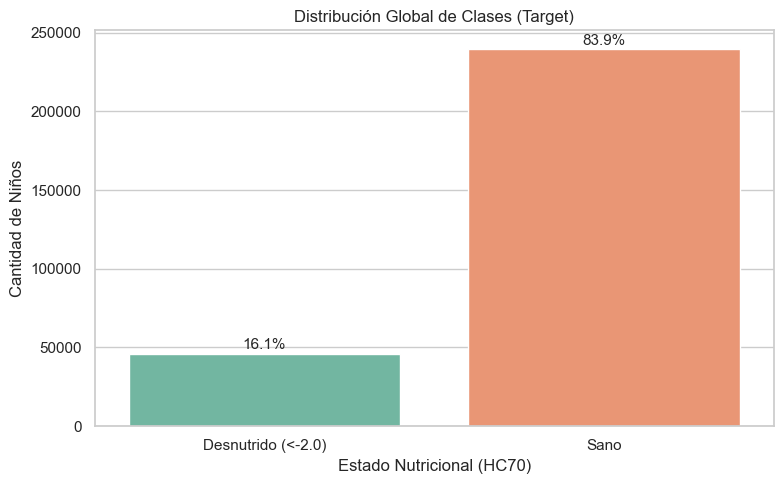

In [10]:
# Crear flag binario de desnutrición crónica
df_rech6['stunting_flag'] = df_rech6['HC70'].apply(lambda x: 'Desnutrido (<-2.0)' if x < -2.0 else ('Sano' if pd.notnull(x) else np.nan))

prevalencia = df_rech6['stunting_flag'].value_counts(normalize=True) * 100
print("Prevalencia Histórica Total (2007-2024):")
print(prevalencia.round(2))

plt.figure(figsize=(8, 5))
sns.countplot(data=df_rech6, x='stunting_flag', palette='Set2')
plt.title("Distribución Global de Clases (Target)")
plt.ylabel('Cantidad de Niños')
plt.xlabel('Estado Nutricional (HC70)')

# Mostrar porcentajes
total = len(df_rech6.dropna(subset=['stunting_flag']))
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2., height + 3000, 
            f'{height/total*100:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

> **Conclusión y Acción (Desbalance de Clases Global)**
> * **Observación:** El *Dataset* presenta un **Desbalance de Clases Moderado (~16% vs ~84%)**. Al agregar todas las décadas, vemos que la clase de interés (niños con desnutrición crónica) representa aproximadamente la sexta parte de los datos. Esta asimetría es un reto clásico en analítica de salud: la clase es lo suficientemente grande para ser aprendida por una IA, pero lo bastante pequeña para que los algoritmos vagos intenten ignorarla.
> * **Acción a Tomar:** **Prohibición del Accuracy.** Queda estrictamente prohibido usar la métrica de Exactitud (*Accuracy*) para evaluar los futuros modelos predictivos (un modelo inútil que prediga que todos los niños están sanos sacaría "84% en el examen"). Nuestras métricas de validación deberán ser **Recall** (Sensibilidad para detectar desnutridos) y **F1-Score**. Además, deberemos usar técnicas de re-ponderación matemática (ej. `class_weight='balanced'`) en el algoritmo para penalizar fuertemente a la IA cuando se equivoque al detectar a un niño enfermo.

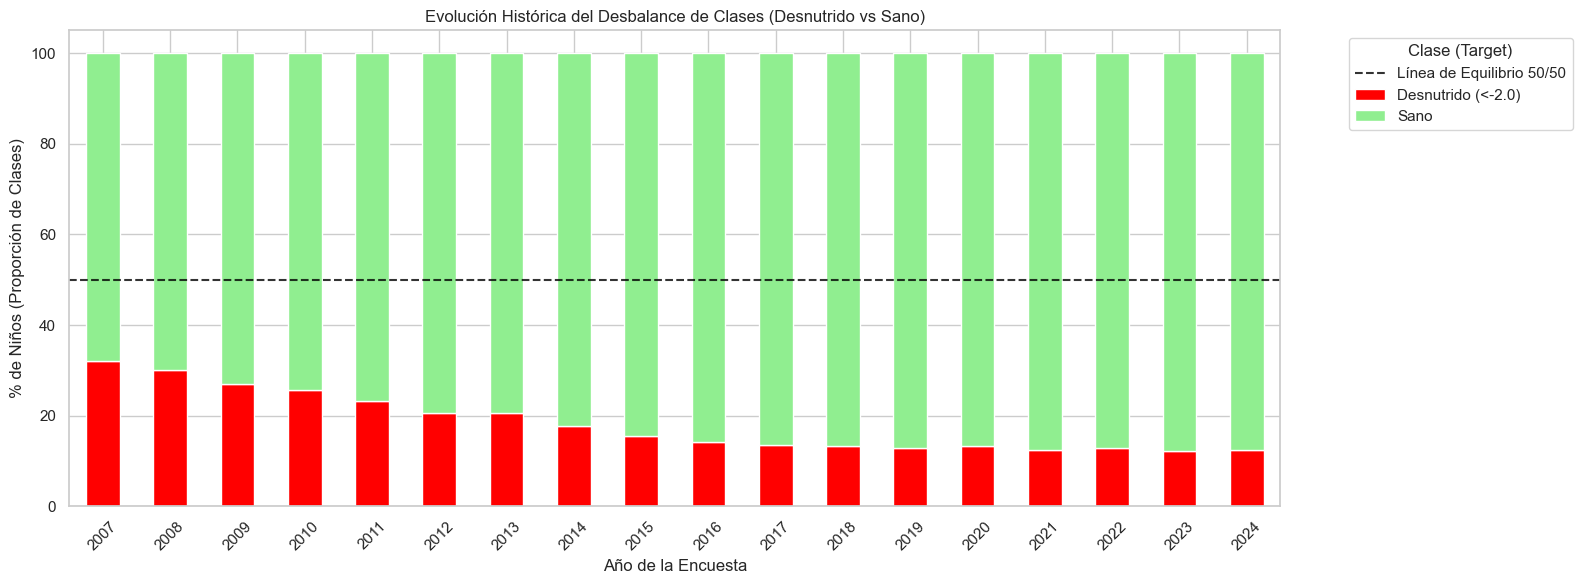

In [11]:
# Evolución Histórica del Desbalance de Clases (Target: stunting_flag) por Año
df_valid = df_rech6.dropna(subset=['stunting_flag'])
class_balance_year = pd.crosstab(df_valid['year'], df_valid['stunting_flag'], normalize='index') * 100

cols = sorted(class_balance_year.columns)
color_map = {'Desnutrido (<-2.0)': 'red', 'Sano': 'lightgreen'}
colors = [color_map.get(c, 'blue') for c in cols]

class_balance_year.plot(kind='bar', stacked=True, figsize=(16, 6), color=colors)
plt.title('Evolución Histórica del Desbalance de Clases (Desnutrido vs Sano)')
plt.ylabel('% de Niños (Proporción de Clases)')
plt.xlabel('Año de la Encuesta')
plt.axhline(50, color='black', linestyle='--', alpha=0.8, label='Línea de Equilibrio 50/50')
plt.legend(title='Clase (Target)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Conclusión y Acción (Evolución Histórica del Desbalance)**
> * **Observación:** El desbalance de clases es **altamente dinámico y no estacionario**. La gráfica es un testimonio estadístico del avance sanitario peruano: en 2007, casi 1 de cada 3 niños (más del 30%) padecía desnutrición crónica. Año tras año, la franja roja se comprime ininterrumpidamente hasta tocar fondo y estabilizarse en un 11-12% durante el último sexenio. Esto significa que la dificultad predictiva ha mutado: predecir desnutrición en 2007 era estadísticamente frecuente, pero predecir desnutrición hoy es identificar una anomalía.
> * **Acción a Tomar:** **Validación Temporal (Time-Series Split).** Dado que la probabilidad base (*prior*) del Target se ha desplomado con el tiempo, realizar un *Train/Test Split* aleatorio tradicional (barajar todas las filas) es metodológicamente incorrecto porque mezclaría contextos históricos distintos. Para evaluar nuestros modelos predictivos, será mandatorio utilizar un **Split Temporal**: entrenar a la IA con los datos del pasado (ej. 2007-2019) y ponerla a prueba simulando el futuro prediciendo exclusivamente sobre la cohorte más reciente (ej. 2020-2024).

### 3.3 Curvas de Acumulación Clínica (Global y Por Año)

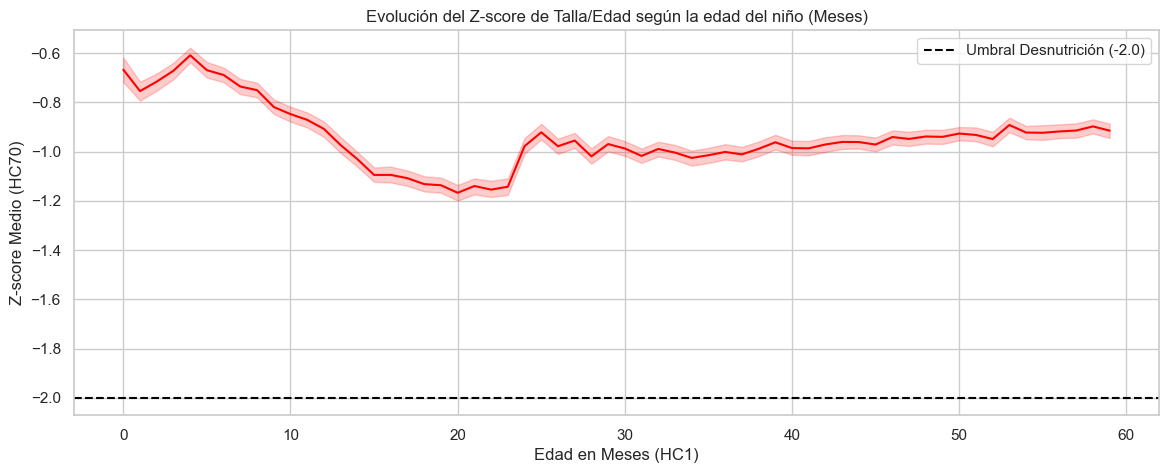

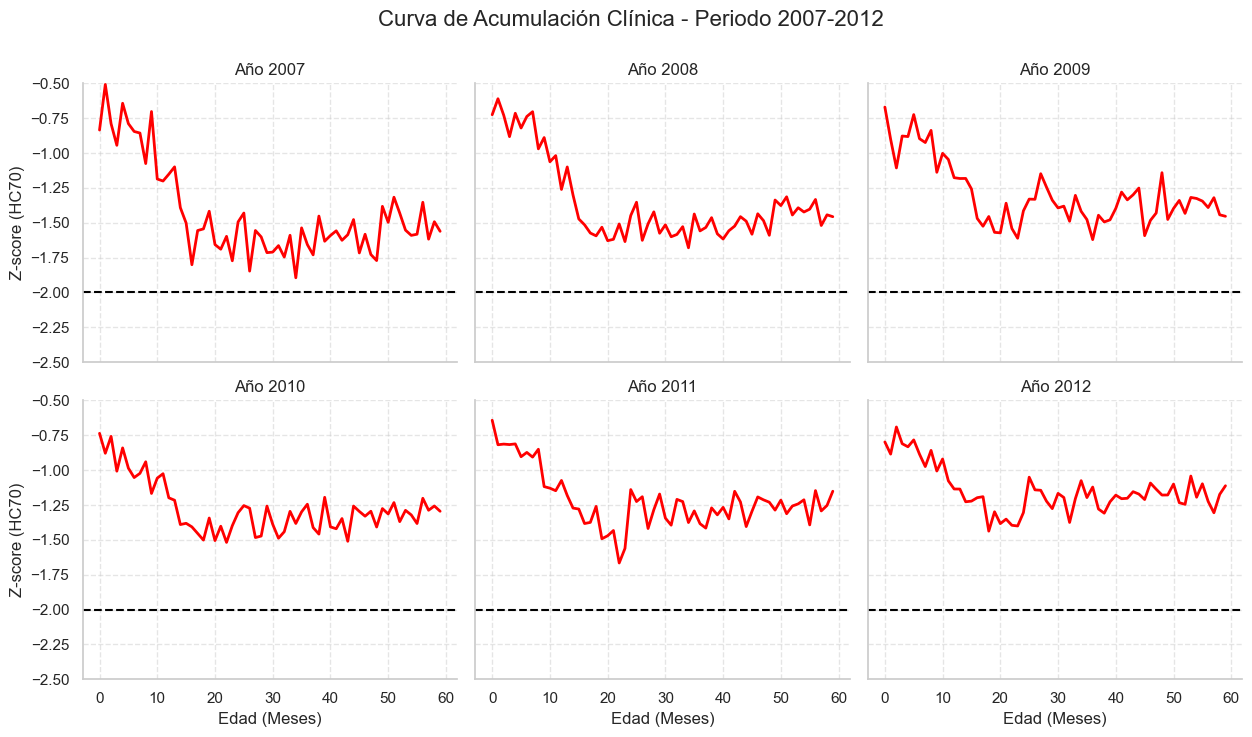

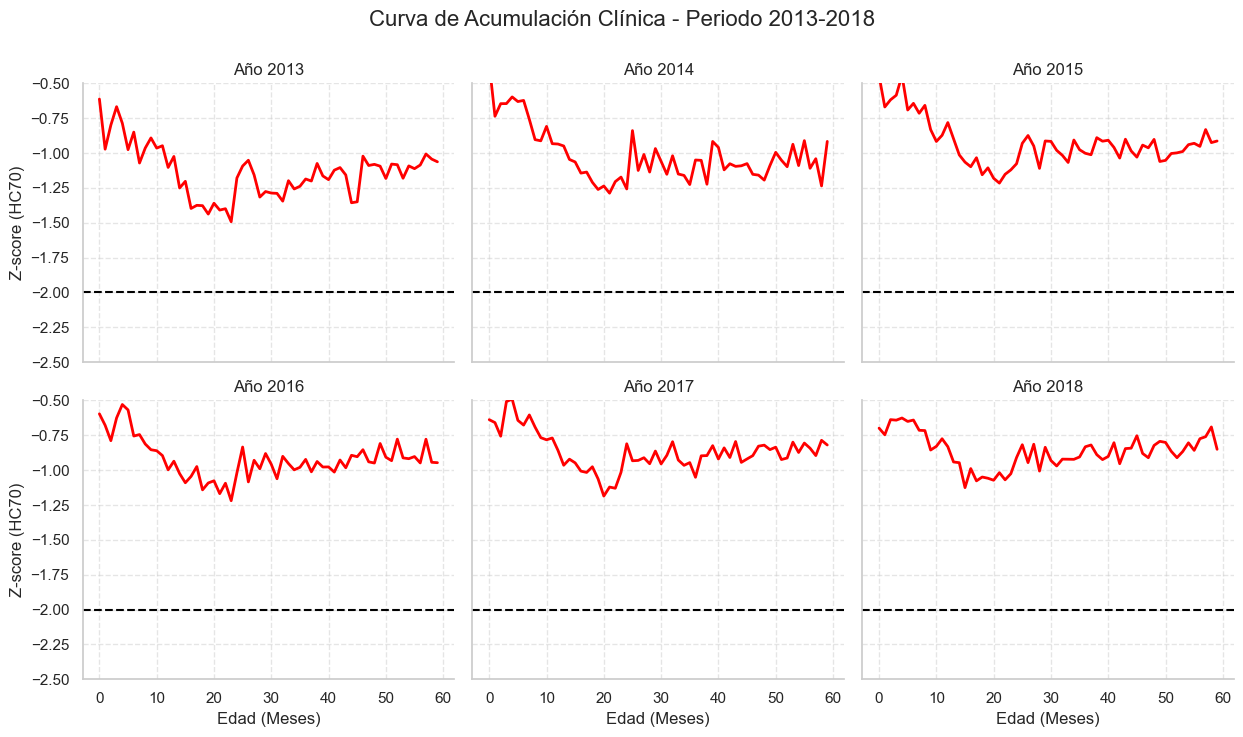

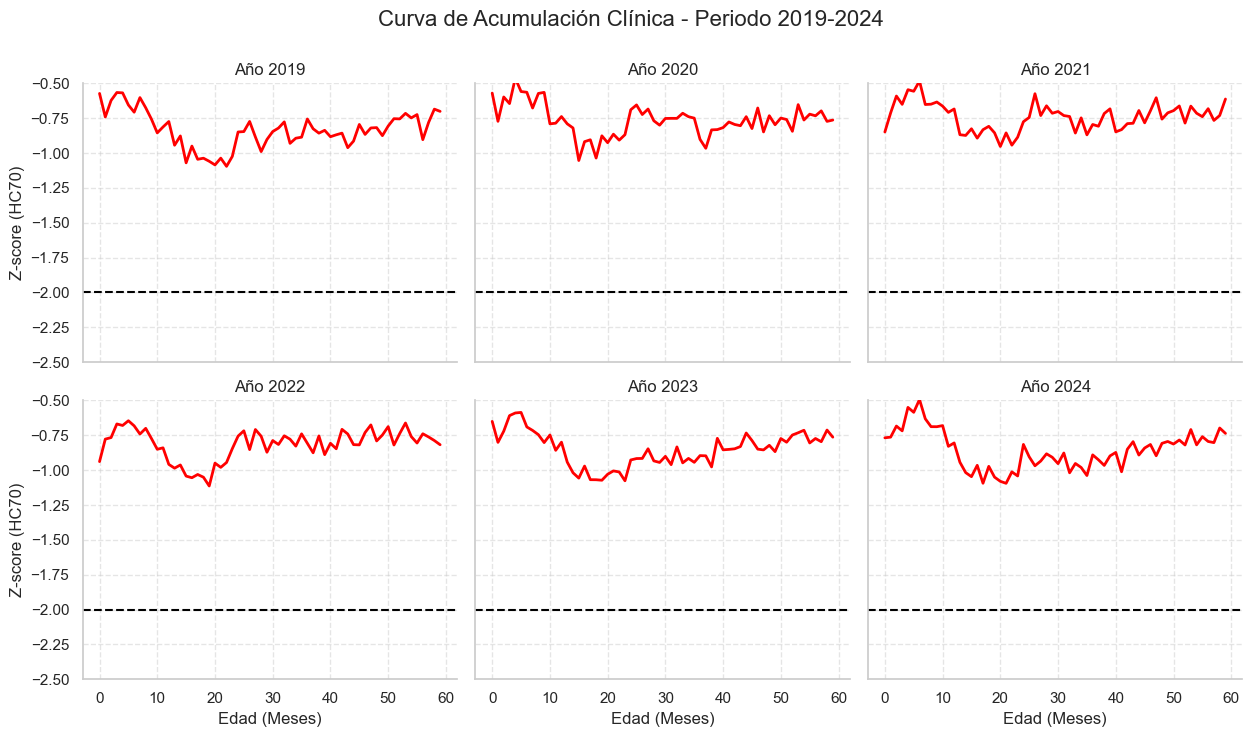

In [12]:
# Promedio de Z-score por Edad en meses (0 a 59 meses)
plt.figure(figsize=(14, 5))
sns.lineplot(data=df_rech6, x='HC1', y='HC70', errorbar='ci', color='red')
plt.axhline(-2.0, ls='--', color='black', label='Umbral Desnutrición (-2.0)')
plt.title("Evolución del Z-score de Talla/Edad según la edad del niño (Meses)")
plt.xlabel("Edad en Meses (HC1)")
plt.ylabel("Z-score Medio (HC70)")
plt.legend()
plt.show()

# 2. Curva Clínica de Acumulación de Desnutrición (18 Gráficas: 6 imágenes por foto)
import pandas as pd
df_rech6['periodo'] = pd.cut(df_rech6['year'], 
                             bins=[2006, 2012, 2018, 2025], 
                             labels=['Periodo 2007-2012', 'Periodo 2013-2018', 'Periodo 2019-2024'])

for periodo in ['Periodo 2007-2012', 'Periodo 2013-2018', 'Periodo 2019-2024']:
    df_periodo = df_rech6[df_rech6['periodo'] == periodo]
    
    g = sns.relplot(
        data=df_periodo, 
        x='HC1', 
        y='HC70', 
        col='year', 
        col_wrap=3, 
        kind='line', 
        color='red', 
        errorbar=None,
        height=3.5, 
        aspect=1.2,
        linewidth=2
    )
    g.map(plt.axhline, y=-2.0, ls='--', color='black', linewidth=1.5)
    g.fig.suptitle(f"Curva de Acumulación Clínica - {periodo}", y=1.05, fontsize=16)
    g.set_axis_labels("Edad (Meses)", "Z-score (HC70)")
    g.set_titles("Año {col_name}")
    
    for ax in g.axes.flat:
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_ylim(-2.5, -0.5) 
    plt.show()

df_rech6 = df_rech6.drop(columns=['periodo'])

> **Conclusión y Acción (Curva Clínica Global Agregada)**
> * **Observación Principal:** Esta es la "radiografía biológica promedio" de los últimos 18 años de infancia en Perú. Evidencia magistralmente la famosa **ventana crítica de los primeros 1000 días**. Los niños nacen con un Z-score aceptable (cerca de -0.6 Z), pero a partir del sexto mes (fin de la lactancia materna exclusiva) sufren una caída estructural, tocando el fondo del abismo nutricional alrededor del mes 20 (-1.2 Z). 
> * **Observación del Salto a los 24 meses:** Se nota un "escalón" o recuperación abrupta justo entre el mes 23 y 24. Esto es clásico en bases de datos sanitarias y responde a dos factores: **1) Artefacto Técnico:** A los 24 meses, la norma de la OMS exige cambiar el método de "longitud acostado" por el de "talla de pie", lo cual genera un ligero desfase matemático en el cálculo del Z-score. **2) Adaptación Biológica:** A los 2 años, el niño ya completó el destete y su flora intestinal/sistema inmunológico se han adaptado a su entorno (menor frecuencia de diarreas), frenando por completo la "caída libre".
> * **Acción a Tomar:** **Modelado No Lineal de la Edad.** La variable `HC1` (Edad en Meses) no tiene una relación matemática lineal con la desnutrición. Un algoritmo estadístico tradicional (Regresión Logística pura) fracasaría miserablemente tratando de trazar una línea recta sobre este profundo valle y su escalón de recuperación. Esta gráfica justifica técnica y biológicamente nuestra futura elección de usar **Algoritmos Basados en Árboles (XGBoost, Random Forest)**, que son expertos en aprender los umbrales exactos de estos "escalones" biológicos ocultos en los datos.

> **Conclusión y Acción (Curvas Clínicas de Acumulación - Histórico)**
> * **Observación 2007-2012 (El Colapso):** La curva tiene una forma de "L" brutal: los bebés nacían protegidos (-0.75 Z), pero del sexto al vigésimo mes sufrían una caída libre, estrellando el promedio nacional contra el abismo de la desnutrición clínica (-1.75 Z). El daño era estructural y masivo.
> * **Observación 2013-2018 (El Amortiguamiento):** El éxito inicial de las políticas públicas. El choque biológico al iniciar la alimentación sólida persiste, pero el "suelo" de la caída se eleva. Para 2018, el fondo del valle se amortigua en -1.0 Z. El daño poblacional se redujo a la mitad.
> * **Observación 2019-2024 (La Estabilización):** El aplanamiento histórico de la curva. La vulnerabilidad sistémica de la ventana de los 1000 días ha sido en gran parte neutralizada a nivel macro. La curva es ahora una onda suave y superficial que flota muy lejos de la zona roja (<-2.0 Z), demostrando resiliencia incluso frente a la pandemia de COVID-19 (2020-2021).
> * **Acción a Tomar:** **Targeting de Riesgo Residual.** Dado que a nivel nacional la curva promedio ya no colapsa, los casos de desnutrición en la actualidad ya no son un fenómeno biológico generalizado, sino **bolsones de riesgo residual altamente concentrados**. Nuestro modelo predictivo de Machine Learning tendrá la dificilísima tarea de encontrar a esos niños específicos que, a diferencia del promedio del país, *sí* siguen colapsando biológicamente después del sexto mes. El algoritmo deberá cazar patrones ocultos cruzando variables socioeconómicas (Riqueza) y geográficas profundas.

## 4. Análisis de Anemia y Variables Secundarias

### 4.1 Validación de Anemia (HC57)

Distribución de Niveles de Anemia (Coalesce):
HC57
4.0    167181
3.0     61394
NaN     35411
2.0     29442
1.0       681
Name: count, dtype: int64


/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_44379/3609773301.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_rech6['HC57'].astype(str), order=df_rech6['HC57'].astype(str).value_counts().index, palette='magma')


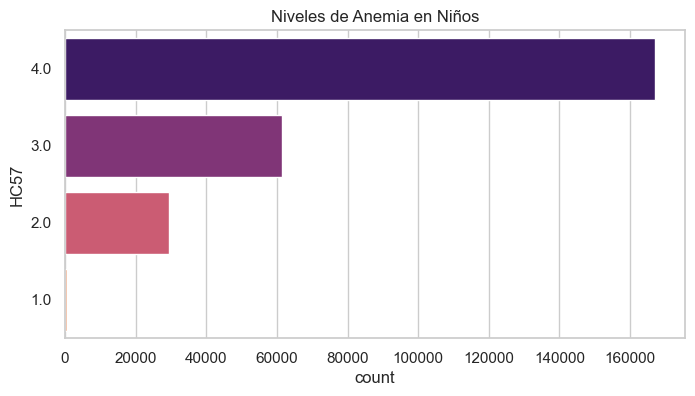

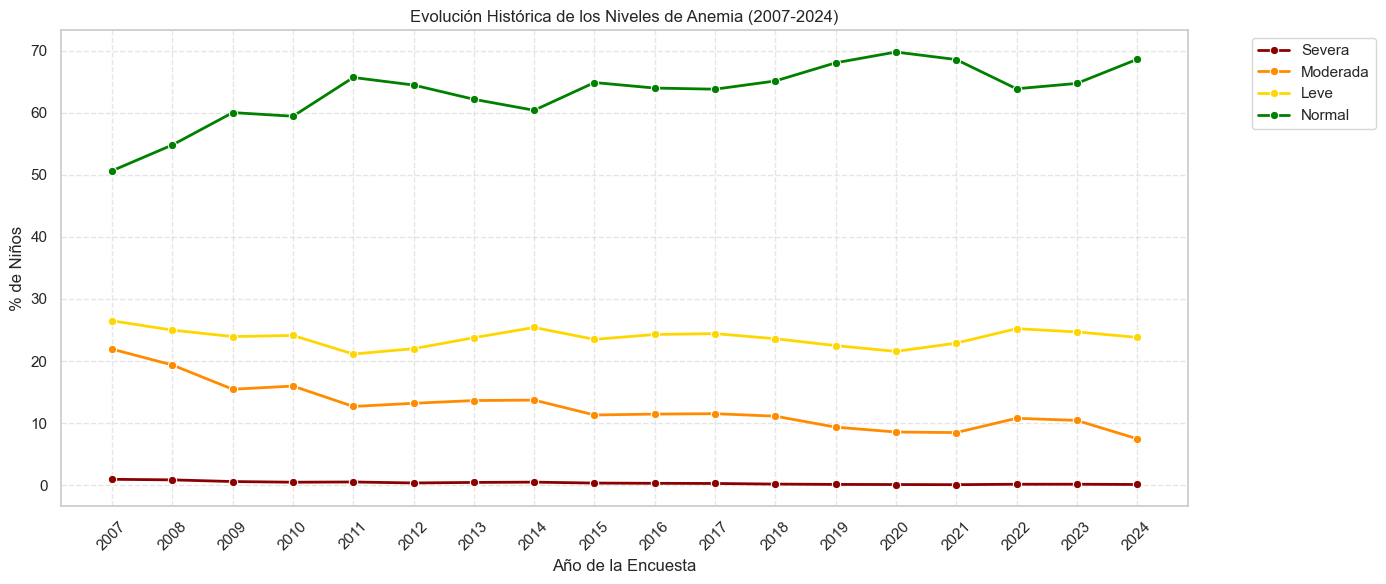

In [13]:
# Validar si el Coalesce funcionó y revisar la distribución
if 'HC57' in df_rech6.columns:
    print("Distribución de Niveles de Anemia (Coalesce):")
    print(df_rech6['HC57'].value_counts(dropna=False))
    
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df_rech6['HC57'].astype(str), order=df_rech6['HC57'].astype(str).value_counts().index, palette='magma')
    plt.title("Niveles de Anemia en Niños")
    plt.show()
else:
    print("La columna HC57 no se encontró en el parquet.")

# Evolución Histórica de los Niveles de Anemia por Año
if 'HC57' in df_rech6.columns:
    df_anemia = df_rech6.dropna(subset=['HC57'])
    anemia_crosstab = pd.crosstab(df_anemia['year'], df_anemia['HC57'], normalize='index') * 100
    
    plt.figure(figsize=(14, 6))
    colores = {4: 'green', 3: 'gold', 2: 'darkorange', 1: 'darkred'}
    
    for nivel in anemia_crosstab.columns:
        label_name = f"Nivel {nivel}"
        if nivel == 4: label_name = 'Normal'
        elif nivel == 3: label_name = 'Leve'
        elif nivel == 2: label_name = 'Moderada'
        elif nivel == 1: label_name = 'Severa'
        
        sns.lineplot(x=anemia_crosstab.index, y=anemia_crosstab[nivel], marker='o', label=label_name, color=colores.get(nivel, 'blue'), linewidth=2)
        
    plt.title('Evolución Histórica de los Niveles de Anemia (2007-2024)')
    plt.ylabel('% de Niños')
    plt.xlabel('Año de la Encuesta')
    plt.xticks(ticks=anemia_crosstab.index, labels=[str(int(y)) for y in anemia_crosstab.index], rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

> **Conclusión y Acción (Niveles de Anemia Agregada 2007-2024)**
> * **Observación:** Al ver el acumulado de los 18 años, el gráfico revela el peso gigantesco de la Anemia en el país. Sumando los casos históricos de Anemia Leve (3.0) y Moderada (2.0), llegamos a unos 90,000 registros, lo que significa que **históricamente** la anemia afectó a una porción enorme de la muestra (casi un tercio global), convirtiéndola en una comorbilidad extremadamente común. La anemia severa (1.0) es afortunadamente marginal.
> * **Acción a Tomar:** **Desglose Temporal Obligatorio.** Dado que este gráfico es una licuadora que mezcla el Perú de 2007 con el Perú de 2024, no podemos asumir que esta prevalencia alta se mantiene igual hoy en día. Esta "fotografía global" nos obliga a realizar inmediatamente el mismo análisis temporal (año por año) que hicimos con la desnutrición crónica, para descubrir si las políticas públicas lograron erradicarla o si la anemia sigue siendo invencible en la actualidad.

> **Conclusión y Acción (Evolución Histórica de la Anemia)**
> * **Observación:** El progreso contra la anemia es asombrosamente lento comparado con la desnutrición. En 2007, solo el 50% de los niños estaba sano (la otra mitad estaba anémica). Aunque la línea verde (Niños Sanos) logra trepar hasta rozar el 70% en 2020, sufre un claro retroceso durante la pandemia (2021-2022), recuperándose recién hacia el 2024. Lo más alarmante es la línea amarilla (Anemia Leve): es una barrera biológica casi inquebrantable que ha flotado alrededor del 25% durante los 18 años enteros, sin inmutarse por las políticas públicas. La Anemia Moderada (naranja) es la única que muestra una reducción estructural real (cayendo del 20% a menos del 10%).
> * **Acción a Tomar:** **Un Enemigo Constante.** Mientras que la desnutrición en 2024 es un fenómeno focalizado (11%), la anemia sigue siendo una epidemia activa que afecta hoy mismo a casi el 30% de los niños. Para nuestro modelo predictivo, esto confirma que la variable `HC57` binarizada (Sano vs Anémico) aportará muchísima información ("señal") sobre el estado de vulnerabilidad general del niño, sin importar el año en el que estemos evaluando. Es un *Feature* dorado.

### 4.2 Distribución de Peso, Talla y Métodos de Medición

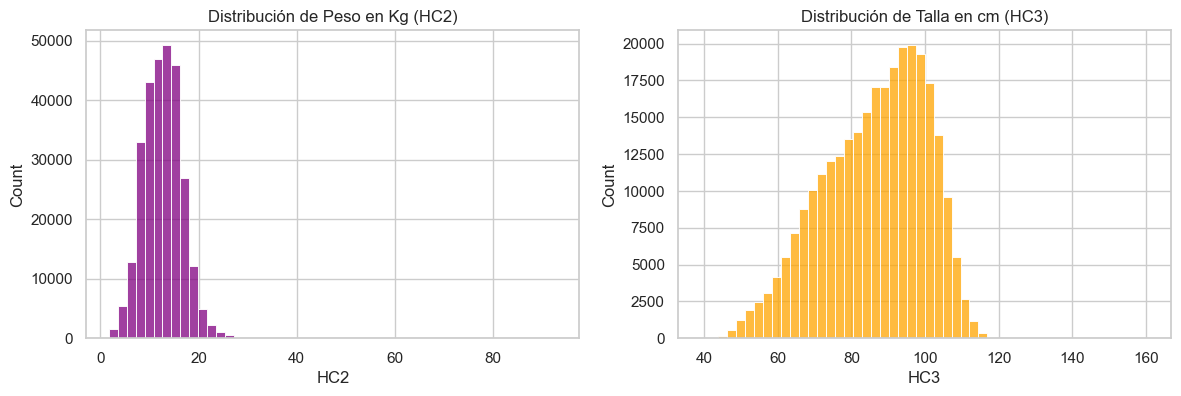

Método de medición (HC15):
HC15
De pie      177405
Acostado    108802
NaN           7902
Name: count, dtype: int64


In [14]:
# 2. Distribución de Peso (HC2) y Talla (HC3) crudos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_rech6['HC2'].dropna(), bins=50, ax=axes[0], color='purple')
axes[0].set_title('Distribución de Peso en Kg (HC2)')
sns.histplot(df_rech6['HC3'].dropna(), bins=50, ax=axes[1], color='orange')
axes[1].set_title('Distribución de Talla en cm (HC3)')
plt.show()

# 3. Cómo fueron medidos (HC15: Acostado vs De pie)
print("Método de medición (HC15):")
print(df_rech6['HC15'].value_counts(dropna=False))

> **Conclusión y Acción (Peso en Kilogramos - HC2)**
> * **Observación:** La distribución del peso crudo muestra una campana asimétrica concentrada entre los 10 y 15 kg, lo cual es biológicamente esperado para la cohorte de 0 a 5 años. Se observan pequeñas colas hacia la derecha que revelan la presencia de códigos de error o datos no medidos (ej. códigos 99 o superiores en la norma DHS) que requerirían limpieza si se fueran a utilizar.
> * **Acción a Tomar:** **Exclusión por Data Leakage.** Esta variable no debe ingresar al modelo predictivo. Dado que el Peso se utiliza en la vida real para calcular los indicadores nutricionales, dársela al algoritmo para predecir desnutrición sería proporcionarle la respuesta camuflada (*Data Leakage* o Fuga de Datos). Se valida su consistencia, pero se descarta para Machine Learning.

> **Conclusión y Acción (Talla en Centímetros - HC3)**
> * **Observación:** La distribución de la talla bruta muestra un escalamiento lineal progresivo desde los 40 cm (recién nacidos) hasta los 120 cm (niños de 5 años). Al igual que el peso, confirma la correcta recolección general, aunque exhibe algunos valores atípicos marginales en el extremo derecho típicos de los códigos de flag de la ENDES.
> * **Acción a Tomar:** **Exclusión Estricta (Data Leakage).** Dado que nuestro Target a predecir (`HC70`) es literalmente el "Z-score de Talla para la Edad", introducir los centímetros crudos de Talla (`HC3`) al modelo haría que este memorice una regla matemática perfecta en lugar de aprender los patrones socioeconómicos que causan la baja talla. Queda estrictamente prohibido usar `HC3` como *feature* predictivo.

> **Conclusión y Acción (Método de Medición - HC15)**
> * **Observación:** Las frecuencias son un reflejo perfecto del protocolo de la OMS: ~38% de los niños (los menores de 2 años) fueron medidos en posición supina ("Acostado"), mientras que el ~62% restante (niños de 2 a 5 años) fueron medidos con tallímetro ("De pie"). Hay un pequeño bloque de valores nulos o códigos especiales (7,902) que coincide con los niños ausentes o no medidos.
> * **Acción a Tomar:** **Descarte Analítico (Correlación Espuria).** Esta variable es una joya para validar la calidad operativa de los encuestadores, pero debe ser eliminada del dataset de Machine Learning. Si la incluimos, el algoritmo caerá en una trampa lógica: *"Si es medido acostado, tiene más riesgo de desnutrición"*. El método de medición no causa desnutrición; solo coincide temporalmente con la edad más crítica (0-2 años). Retirarla evita una falsa correlación (*Correlación Espuria*).

## 10. Justificación de Variables Excluidas del Análisis Visual

El archivo parquet cuenta con un total de 38 variables. Hemos auditado visualmente las 9 más críticas (Target OMS, Anemia, Peso, Talla, Edad, Sexo, Nulos, Posicion). Las 29 variables restantes se conservan en esta etapa intermedia (Interim/Silver) por reglas estrictas de Arquitectura de Datos, pero no se graficaron por las siguientes razones:

*   **Llaves Maestras y de Control (10 variables)**: `HHID`, `HC0`, `year`, `HC51`, `HC60`, etc. Son IDs alfanuméricos puros y números de línea de los padres. Son vitales para cruzar módulos (Joins), pero imposibles de graficar.
*   **Métricas de Tiempo y Fechas (8 variables)**: `HC16`, `HC19`, `HC30`, `HC31`, `HC32`, `HC33`, etc. Registran el día/mes/año exacto de la entrevista y nacimiento. Clínicamente, la variable Edad en meses (`HC1`) que ya analizamos resume matemáticamente toda esta maraña de fechas.
*   **Z-scores Obsoletos NCHS (11 variables)**: `HC4` a `HC12`. Son percentiles y cálculos de desnutrición basados en el antiguo estándar de EE.UU. (NCHS/CDC 1977). Actualmente la comunidad internacional usa el estándar OMS 2006 (`HC70` a `HC73`). Se conservan en el parquet temporalmente como "copia de seguridad" científica por si toca auditar algún error de cálculo del INEI.
*   **Métricas de Control de Sangre**: `HC53` y `HC55` son simples controles de si la madre aceptó o si el test se leyó bien. `HC56` es la hemoglobina cruda, pero su verdadera interpretación clínica y de riesgo ya está encapsulada en la variable final `HC57` (Nivel de Anemia ordinal) que sí analizamos a fondo.

**Nota para la Fase 4 (Feature Selection)**: Durante la creación del Dataset Final de Entrenamiento (Processed/Gold), estas 29 variables serán eliminadas permanentemente, ya que introducirlas a un modelo de Machine Learning generaría ruido o "Fuga de Datos" (Data Leakage).


## Análisis de Nulidad Estructural (Missing Values) - RECH6 (Características de la Vivienda)

Para garantizar la integridad del modelo de Machine Learning, sometemos las variables preservadas en este módulo a una prueba de nulidad histórica. 
Cualquier variable que supere el **umbral de riesgo del 60%** será considerada ruido estadístico (Data Drift) y será una candidata principal para su eliminación en la fase de *Feature Engineering*.

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_44379/25645119.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_nulls.head(30), x='Nulidad_Porcentaje', y='Desc', palette='Reds_r')


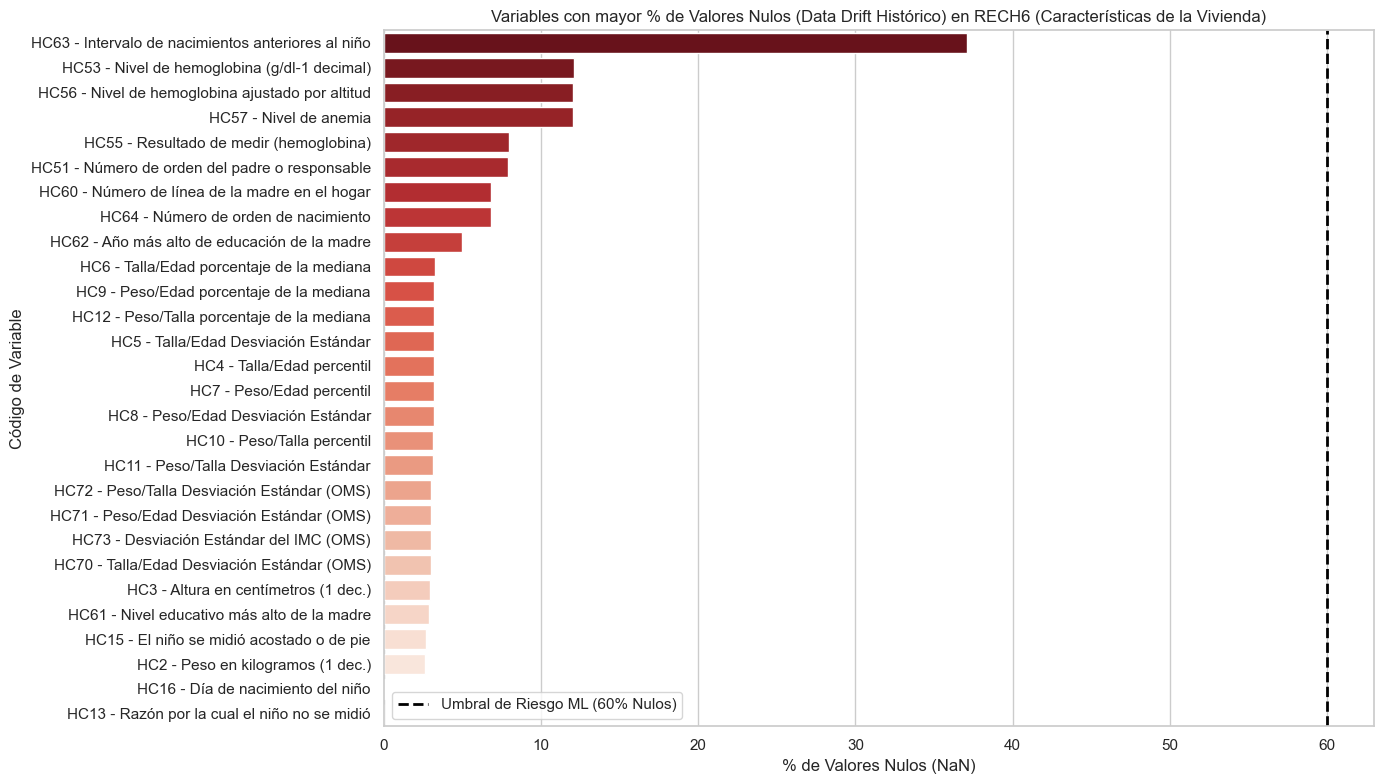

In [15]:
from mnp.config import INTERIM_DATA_DIR
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_missing = pd.read_parquet(INTERIM_DATA_DIR / 'rech6_cleaned.parquet')

nulls = df_missing.isnull().sum()
nulls_pct = (nulls / len(df_missing)) * 100
df_nulls = pd.DataFrame({'Variable': nulls_pct.index, 'Nulidad_Porcentaje': nulls_pct.values})
from mnp.configs.column_labels import LABELS
df_nulls['Desc'] = df_nulls['Variable'].map(lambda x: LABELS.get(x, x))
import textwrap
df_nulls['Desc'] = df_nulls['Desc'].apply(lambda x: textwrap.fill(str(x), width=50))
df_nulls = df_nulls[df_nulls['Nulidad_Porcentaje'] > 0].sort_values('Nulidad_Porcentaje', ascending=False)

plt.figure(figsize=(14, 8))
if len(df_nulls) > 0:
    sns.barplot(data=df_nulls.head(30), x='Nulidad_Porcentaje', y='Desc', palette='Reds_r')
    plt.title('Variables con mayor % de Valores Nulos (Data Drift Histórico) en RECH6 (Características de la Vivienda)')
    plt.xlabel('% de Valores Nulos (NaN)')
    plt.ylabel('Código de Variable')
    plt.axvline(x=60, color='black', linestyle='--', linewidth=2, label='Umbral de Riesgo ML (60% Nulos)')
    plt.legend()
else:
    plt.text(0.5, 0.5, '¡Cero Valores Nulos detectados en este Dataset!', 
             horizontalalignment='center', verticalalignment='center', fontsize=20, color='green')
    plt.axis('off')

plt.tight_layout()
plt.show()

> **Implicación para el Modelado:** Todo aquello que cruce la línea punteada negra (60%) nos indica que la pregunta no se realizó sistemáticamente a lo largo de los 18 años, o bien dependía de una sub-muestra muy pequeña. Intentar imputar estas variables destruiría la varianza del modelo.